## IMPORTING IMPORTANT LIBRARIES 

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [190]:
data=pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv",header=1)

In [191]:
data

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
242,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
243,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
244,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [192]:
data[data.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [193]:
data.loc[:122,'Region']=0
data.loc[122:,'Region']=1
df=data

In [194]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [195]:
df=df.dropna().reset_index(drop=True)

In [196]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1.0


In [197]:
df=df.drop(122).reset_index(drop=True)

In [198]:
df['Region']=df['Region'].astype(int)

In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    object
 1   month        243 non-null    object
 2   year         243 non-null    object
 3   Temperature  243 non-null    object
 4    RH          243 non-null    object
 5    Ws          243 non-null    object
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 28.6+ KB


In [200]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [201]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [202]:
df.columns=df.columns.str.strip()

In [203]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [204]:
## changing the datatype of the req columns to int data type
cols = ["day", "month", "year", "Temperature", "RH", "Ws"]

df[cols] = df[cols].astype(int)

In [205]:
vals=[x for x in df.columns if df[x].dtypes=="O"]
vals

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

In [206]:
for i in vals:
    if i!="Classes":
        df[i]=df[i].astype(float)

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [208]:
df_copy=df.drop(['day', 'month', 'year'],axis=1)

In [209]:
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)

In [210]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [211]:
df_copy["Classes"].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

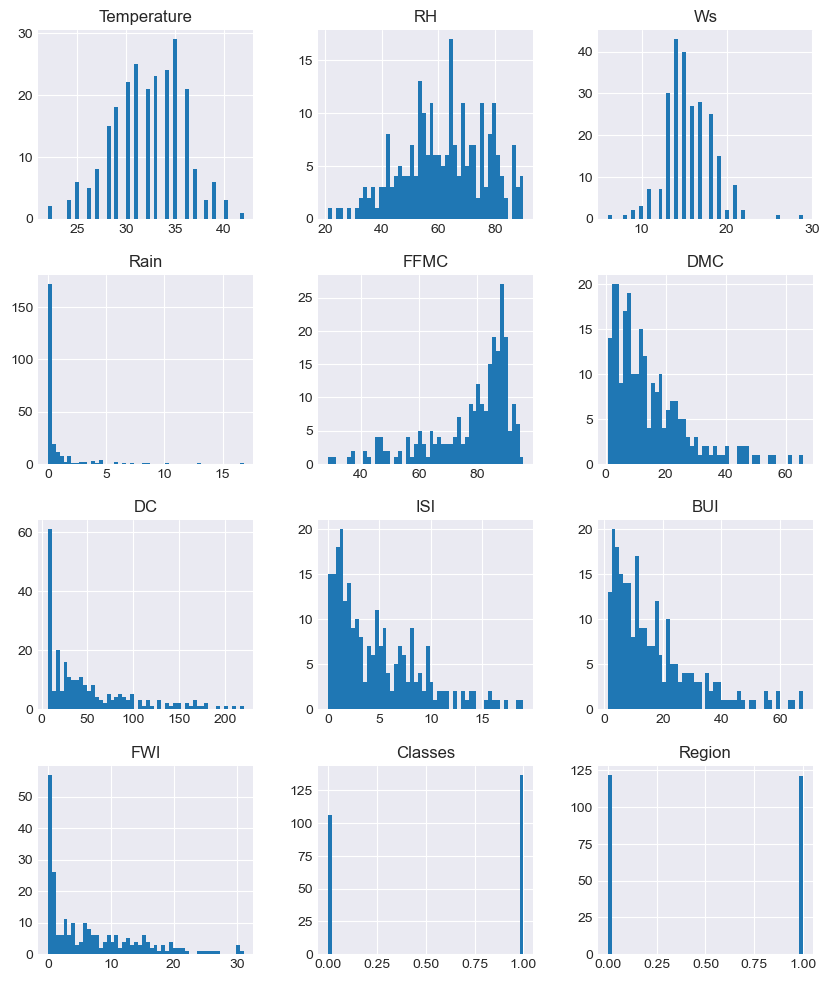

In [212]:
plt.style.use("seaborn-v0_8-darkgrid")
df_copy.hist(bins=50,figsize=(10,12))
plt.show()

In [213]:
percentage=df_copy['Classes'].value_counts(normalize=True)*100
percentage

Classes
1    56.378601
0    43.621399
Name: proportion, dtype: float64

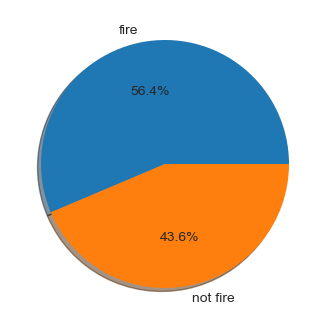

In [214]:
plt.figure(figsize=(4,5))
labels=["fire","not fire"]
plt.pie(percentage,labels=labels,autopct="%1.1f%%",shadow=True)
plt.show()

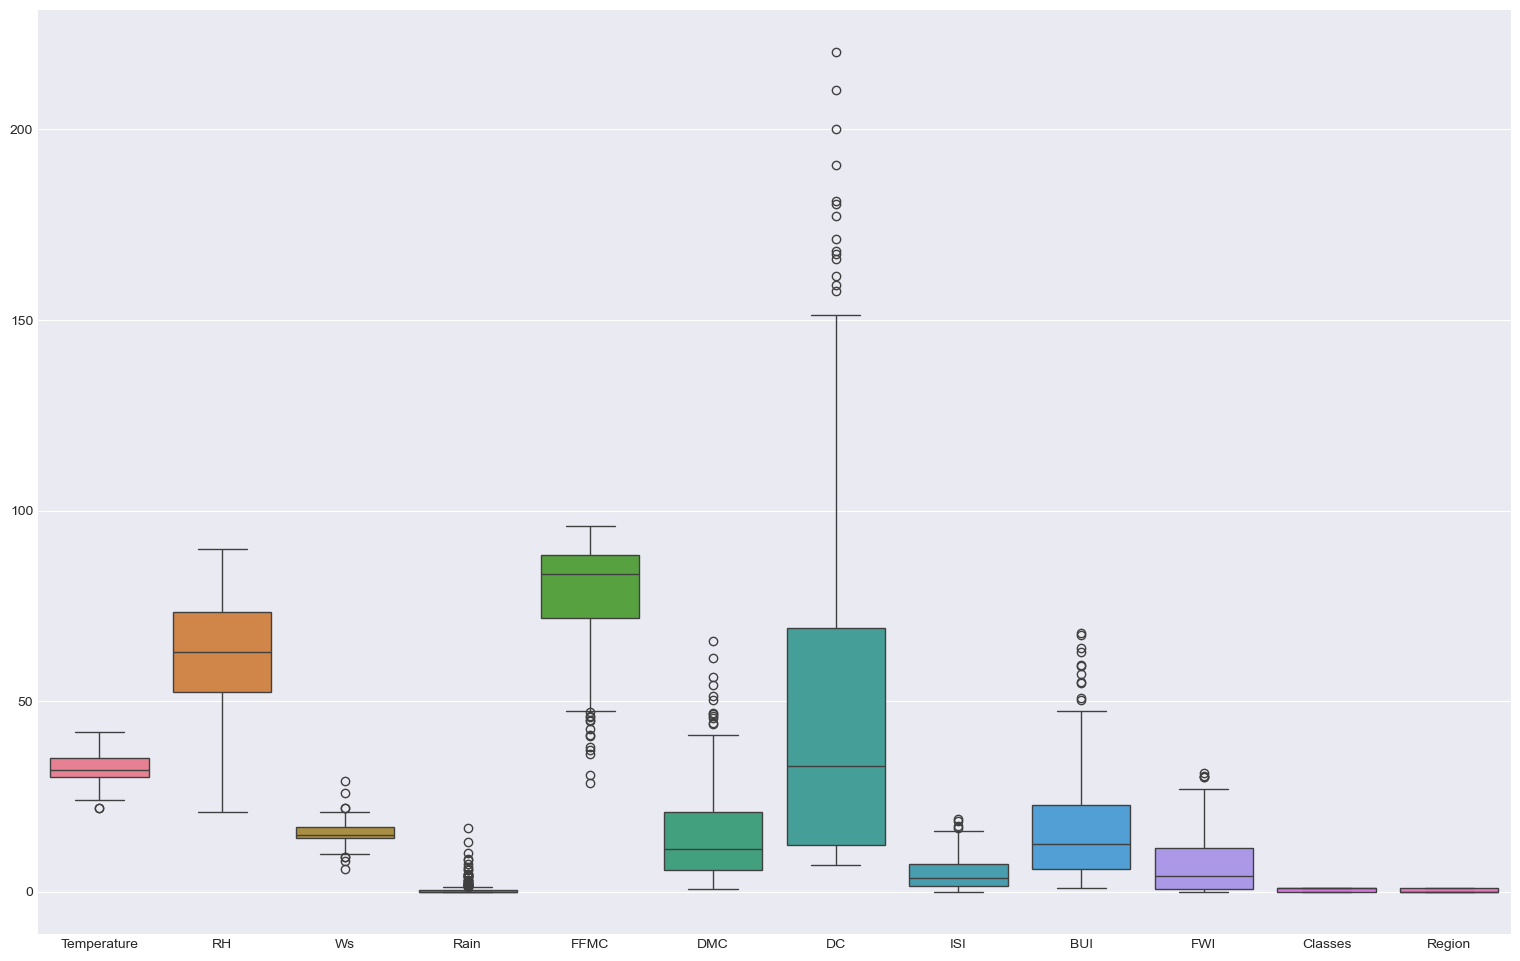

In [215]:
import seaborn as sns
plt.figure(figsize=(19,12))
sns.boxplot(data=df_copy)
plt.show()

In [216]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),'not fire','fire')

## MONTHLY FIRE ANALYSIS

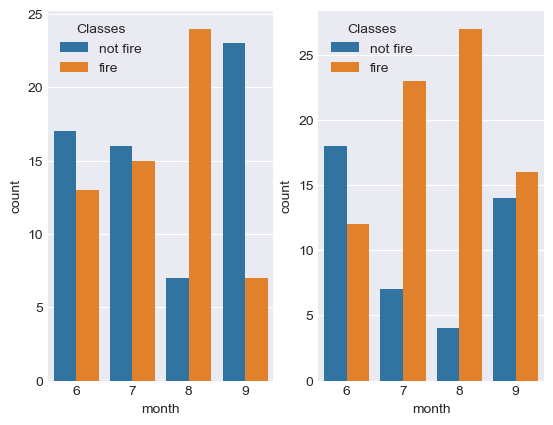

In [218]:

import seaborn as sns
df_temp=df.loc[df['Region']==0]
plt.subplot(1,2,1)
sns.countplot(x='month',hue="Classes",data=df_temp)
df_temp2=df.loc[df['Region']==1]
plt.subplot(1,2,2)
sns.countplot(x='month',hue="Classes",data=df_temp2)
plt.show()

In [219]:
## TAKING X AND Y VALUES
x=df_copy.drop('FWI',axis=1)
y=df_copy['FWI']

In [220]:
##Train Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

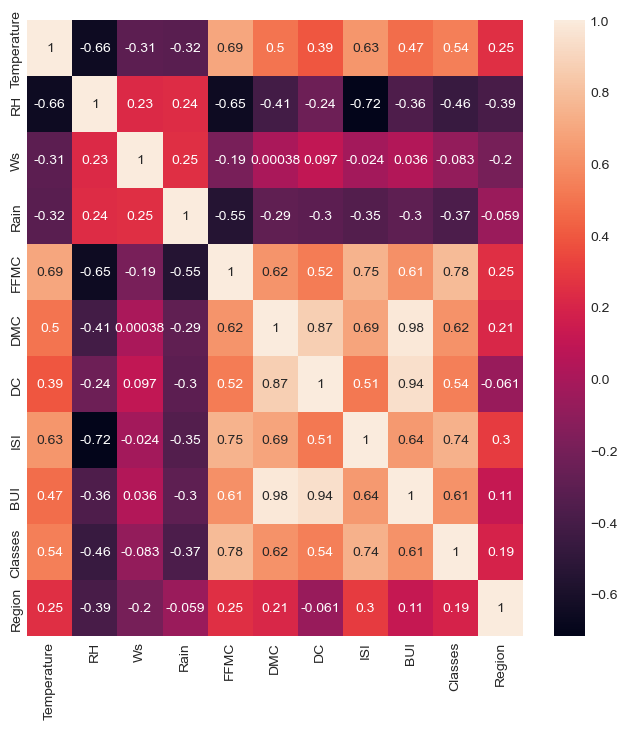

In [221]:
import seaborn as sns
plt.figure(figsize=(8,8))
corr=x_train.corr()
sns.heatmap(corr,annot=True)
plt.show()

In [222]:
corr_matrix=corr.abs()
upper=corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
x=[col for col in upper.columns if any(upper[col]>0.85)]
x                                                                                                                                                             

['DC', 'BUI']

In [223]:
x_train.shape,x_test.shape

((182, 11), (61, 11))

In [224]:
x_train.drop(x,axis=1,inplace=True)
x_test.drop(x,axis=1,inplace=True)

In [247]:
x_train.shape,x_test.shape

((182, 9), (61, 9))

In [248]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

## LINEAR REGRESSION MODEL

mean_squared_error:0.6742766873791581
mean_absolute_error:0.5468236465249976
R^2 Score:0.9847657384266951


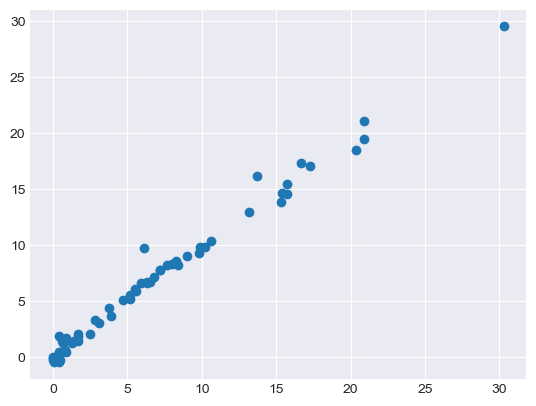

In [250]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
model=LinearRegression()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
print(f"mean_squared_error:{mse}")
mae=mean_absolute_error(y_test,y_pred)
print(f"mean_absolute_error:{mae}")
score=r2_score(y_test,y_pred)
print(f"R^2 Score:{score}")
plt.scatter(y_test,y_pred)
plt.show()

## LASSO REGRESSION

mean_squared_error:2.2483458918974746
mean_absolute_error:1.1331759949144085
R^2 Score:0.9492020263112388


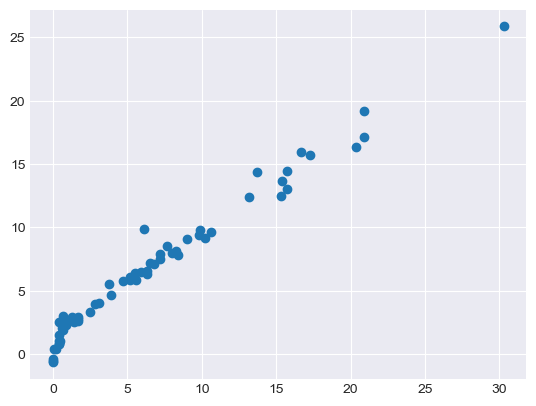

In [252]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
model=Lasso()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
print(f"mean_squared_error:{mse}")
mae=mean_absolute_error(y_test,y_pred)
print(f"mean_absolute_error:{mae}")
score=r2_score(y_test,y_pred)
print(f"R^2 Score:{score}")
plt.scatter(y_test,y_pred)
plt.show()

## Ridge Regression

mean_squared_error:0.6949198918152067
mean_absolute_error:0.5642305340105693
R^2 Score:0.9842993364555513


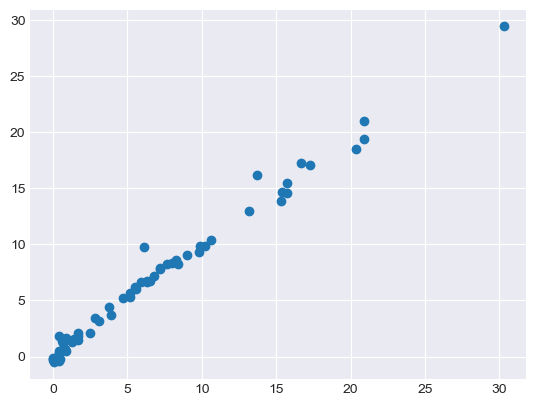

In [299]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(x_train_scaled,y_train)
y_pred=ridge.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
print(f"mean_squared_error:{mse}")
mae=mean_absolute_error(y_test,y_pred)
print(f"mean_absolute_error:{mae}")
score=r2_score(y_test,y_pred)
print(f"R^2 Score:{score}")
plt.scatter(y_test,y_pred)
plt.show()

## EALSTIC NET REGRESSION

mean_squared_error:5.517251101025224
mean_absolute_error:1.8822353634896
R^2 Score:0.8753460589519703


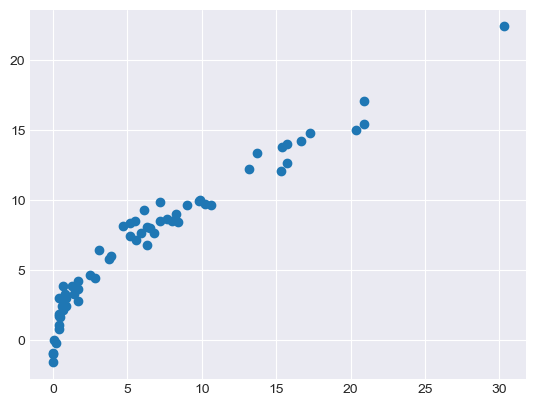

In [256]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
model=ElasticNet()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
print(f"mean_squared_error:{mse}")
mae=mean_absolute_error(y_test,y_pred)
print(f"mean_absolute_error:{mae}")
score=r2_score(y_test,y_pred)
print(f"R^2 Score:{score}")
plt.scatter(y_test,y_pred)
plt.show()

## LASSOCV 

mean_squared_error:0.7924995554743622
mean_absolute_error:0.6199701158263431
R^2 Score:0.9820946715928275


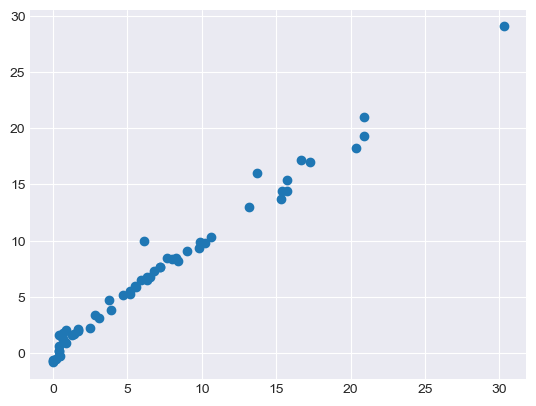

In [294]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
model=LassoCV(cv=5)
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
print(f"mean_squared_error:{mse}")
mae=mean_absolute_error(y_test,y_pred)
print(f"mean_absolute_error:{mae}")
score=r2_score(y_test,y_pred)
print(f"R^2 Score:{score}")
plt.scatter(y_test,y_pred)
plt.show()

In [ ]:
##PICKLING RIDGE AND PREPROCESSING MODEL STANDARDSCALER


In [303]:
scaler

StandardScaler()

In [305]:
ridge

Ridge()

In [309]:
import pickle
pickle.dump(scaler,open("scaler.pkl",'wb'))
pickle.dump(ridge,open("ridge.pkl",'wb'))